# 📊 Análise Profunda dos Experimentos de Federated Learning

Este notebook realiza uma análise completa e comparativa dos experimentos de Federated Learning usando o framework **LetsFed**.

## 🎯 Objetivos:
- Comparar diferentes **estratégias de treinamento** no cliente (Normal, LetsFed, MaxFL, FedPer, QFFL)
- Avaliar diferentes **métodos de seleção** no servidor (Random, Round Robin, POC, DEEV, LetsFed)
- Analisar diferentes **métodos de agregação** (FedAvg, MaxFL, QFFL)
- Identificar padrões de convergência, fairness e participação dos clientes
- Validar reprodutibilidade dos experimentos

---


## 1️⃣ Importar Bibliotecas e Configuração


In [27]:
# Importar bibliotecas necessárias
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Configurar tamanho padrão das figuras
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

# Exibir todas as colunas do DataFrame
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 100)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2️⃣ Carregar Dados dos Experimentos


In [ ]:
# Definir caminho para os logs
logs_path = Path("../logs")


# Função para carregar logs do servidor
def load_server_logs() -> pd.DataFrame:
    server_files = sorted(logs_path.glob("s-data_*.csv"))

    all_server_data = []

    for file in server_files:
        # Extrair método de seleção do nome do arquivo
        selection_method = file.stem.replace("s-data_", "")

        df = pd.read_csv(file)
        df["experiment"] = selection_method
        all_server_data.append(df)

    # Combinar todos os dados
    server_df = pd.concat(all_server_data, ignore_index=True)

    return server_df


# Carregar dados do servidor
server_df = load_server_logs()

print(f"📊 Dados do Servidor carregados: {len(server_df)} registros")
print(f"📁 Experimentos encontrados: {sorted(server_df['experiment'].unique())}")
print("\n🔍 Primeiras linhas:")
display(server_df)

📊 Dados do Servidor carregados: 10 registros
📁 Experimentos encontrados: ['random']

🔍 Primeiras linhas:


,rounds,model_type,n_selected,selection,dataset,init_clients,participating_state,number_of_participating,number_of_non_participating,training_method,aggregation_method,selection_method,loss,accuracy,precision,recall,f1_score,auc,experiment
0,1,cnn,5,[0;1;2;3;4],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,1.330872,0.5488,0.738251,0.548990,0.539610,0.967380,random
1,2,cnn,3,[2;4;0],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,1.048852,0.6382,0.735038,0.638974,0.618044,0.972617,random
2,3,cnn,3,[4;3;2],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,1.001578,0.6847,0.733499,0.684819,0.658984,0.975840,random
3,4,cnn,3,[4;1;2],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.690493,0.7596,0.800220,0.759781,0.736754,0.982101,random
4,5,cnn,3,[2;1;4],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.700882,0.7536,0.802234,0.753471,0.730030,0.982023,random
5,6,cnn,3,[3;4;0],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.447106,0.8333,0.869951,0.831952,0.828051,0.988078,random
6,7,cnn,3,[2;4;3],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.605351,0.8064,0.800223,0.806287,0.786830,0.986971,random
7,8,cnn,3,[4;0;3],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.466567,0.8366,0.853643,0.835233,0.830260,0.988688,random
8,9,cnn,3,[4;3;2],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.564389,0.8118,0.801630,0.811623,0.791022,0.987625,random
9,10,cnn,3,[4;2;3],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,random,0.598294,0.8100,0.799824,0.809955,0.789149,0.987416,random


In [ ]:
# Função para carregar logs dos clientes
def load_client_logs() -> pd.DataFrame:
    client_files = sorted(logs_path.glob("c-data-*_*.csv"))

    all_client_data = []

    for file in client_files:
        # Extrair ID do cliente e método do nome do arquivo
        parts = file.stem.split("_")
        client_id = parts[0].replace("c-data-", "")
        experiment = "_".join(parts[1:])

        # ⚠️ SOLUÇÃO CORRETA: Extrair 'name' dos dicionários diretamente da linha
        import re

        data_rows = []
        with open(file, "r") as f:
            # Ler header
            header = f.readline().strip().split(",")

            # Processar cada linha
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Encontrar os 3 valores de 'name' nos dicionários
                # Padrão: 'name': 'VALOR'
                name_matches = re.findall(r"'name':\s*'([^']+)'", line)

                if len(name_matches) >= 3:
                    # Pegar os 3 últimos (training, aggregation, selection)
                    dict_names = name_matches[-3:]

                    # Remover tudo após eval_test_loss (última coluna numérica antes dos dicts)
                    # Pegar só as 25 primeiras colunas (todas numéricas/booleanas)
                    match = re.match(r"^((?:[^,]*,){24}[^,]*),", line)
                    if match:
                        numeric_part = match.group(1)
                        normal_cols = numeric_part.split(",")

                        # Combinar com os nomes extraídos
                        row = normal_cols + dict_names
                    else:
                        # Fallback: tentar split normal e pegar primeiras 25 colunas
                        parts = line.split(",")[:25]
                        row = parts + dict_names
                else:
                    # Se não encontrou 3 dicionários, usar split normal
                    row = line.split(",")[: len(header)]

                # Ajustar para o número correto de colunas
                if len(row) > len(header):
                    row = row[: len(header)]
                elif len(row) < len(header):
                    row.extend(["unknown"] * (len(header) - len(row)))

                data_rows.append(row)

        # Criar DataFrame
        df = pd.DataFrame(data_rows, columns=header)

        # Converter tipos de dados
        numeric_cols = [
            "rounds",
            "cid",
            "model_size",
            "model_total_params",
            "model_mean_params",
            "fit_train_accuracy",
            "fit_train_precision",
            "fit_train_recall",
            "fit_train_f1_score",
            "fit_train_auc",
            "fit_train_loss",
            "fit_val_accuracy",
            "fit_val_precision",
            "fit_val_recall",
            "fit_val_f1_score",
            "fit_val_auc",
            "fit_val_loss",
            "eval_test_accuracy",
            "eval_test_precision",
            "eval_test_recall",
            "eval_test_f1_score",
            "eval_test_auc",
            "eval_test_loss",
        ]

        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        # Converter booleanos
        bool_cols = ["participating_state", "selected"]
        for col in bool_cols:
            if col in df.columns:
                df[col] = df[col].map({"True": True, "False": False, True: True, False: False})

        df["experiment"] = experiment
        df["client_id_file"] = int(client_id)
        all_client_data.append(df)

    # Combinar todos os dados
    if all_client_data:
        client_df = pd.concat(all_client_data, ignore_index=True)

        # Reordenar colunas: client_id_file logo no início (após rounds)
        cols = client_df.columns.tolist()

        # Criar nova ordem: começar com as colunas principais
        new_order = ["client_id_file", "experiment", "rounds", "cid"]

        # Adicionar o restante das colunas (exceto as que já estão em new_order)
        remaining_cols = [col for col in cols if col not in new_order]

        # Ordem final
        final_order = new_order + remaining_cols

        # Reordenar o DataFrame
        client_df = client_df[final_order]

        return client_df
    else:
        return None


# Carregar dados dos clientes
client_df = load_client_logs()

if client_df is not None:
    print(f"📊 Dados dos Clientes carregados: {len(client_df)} registros")
    print(f"👥 Clientes únicos: {sorted(client_df['cid'].unique())}")
    print(f"📁 Experimentos encontrados: {sorted(client_df['experiment'].unique())}")
    print("\n🔍 Primeiras linhas:")
    display(client_df)
else:
    print("⚠️ Nenhum dado de cliente encontrado")

📊 Dados dos Clientes carregados: 32 registros
👥 Clientes únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
📁 Experimentos encontrados: ['random']

🔍 Primeiras linhas:


,client_id_file,experiment,rounds,cid,participating_state,selected,model_size,model_total_params,model_mean_params,fit_train_accuracy,fit_train_precision,fit_train_recall,fit_train_f1_score,fit_train_auc,fit_train_loss,fit_val_accuracy,fit_val_precision,fit_val_recall,fit_val_f1_score,fit_val_auc,fit_val_loss,eval_test_accuracy,eval_test_precision,eval_test_recall,eval_test_f1_score,eval_test_auc,eval_test_loss,training_method,aggregation_method,selection_method
0,0,random,1,0,True,True,387368,96842,0.307567,0.885306,0.888119,0.792981,0.882745,0.990076,0.557541,0.865885,0.868889,0.771620,0.862347,0.987207,0.474129,0.5560,0.737099,0.554832,0.547039,0.966377,1.323116,normal,fedavg,random
1,0,random,2,0,True,True,387368,96842,0.469453,0.908391,0.901177,0.845562,0.906587,0.993626,0.408344,0.874679,0.851266,0.808145,0.871806,0.988939,0.354230,0.6860,0.726484,0.690510,0.655431,0.974543,0.880967,normal,fedavg,random
2,0,random,6,0,True,True,387368,96842,0.575072,0.929095,0.923188,0.877466,0.927988,0.996147,0.320073,0.899963,0.893349,0.846473,0.897960,0.992450,0.284441,0.8625,0.876440,0.863725,0.865307,0.989364,0.382499,normal,fedavg,random
3,0,random,8,0,True,True,387368,96842,0.599121,0.939722,0.939202,0.902004,0.939025,0.997071,0.296628,0.897398,0.878019,0.849954,0.895598,0.992782,0.267528,0.8615,0.879002,0.862682,0.864335,0.989933,0.375138,normal,fedavg,random
4,1,random,1,1,True,True,387368,96842,0.307567,0.909816,0.862872,0.828602,0.900565,0.990836,0.503304,0.889902,0.840727,0.813494,0.877877,0.986114,0.488849,0.5390,0.728887,0.546086,0.528737,0.962864,1.359918,normal,fedavg,random
5,1,random,4,1,True,True,387368,96842,0.479796,0.932515,0.915055,0.873003,0.927890,0.995405,0.311287,0.899018,0.863079,0.833486,0.893006,0.990489,0.279879,0.7865,0.839507,0.789418,0.769557,0.983946,0.574856,normal,fedavg,random
6,1,random,5,1,True,True,387368,96842,0.540195,0.940491,0.929184,0.880849,0.937649,0.996071,0.276120,0.904628,0.876417,0.837805,0.899475,0.989735,0.262964,0.7765,0.844269,0.779663,0.760579,0.983606,0.593775,normal,fedavg,random
7,2,random,1,2,True,True,387368,96842,0.307567,0.913039,0.899419,0.871320,0.912819,0.000000,0.469498,0.882306,0.864501,0.817619,0.881476,0.000000,0.478133,0.5600,0.747229,0.552058,0.554032,0.968843,1.318670,normal,fedavg,random
8,2,random,2,2,True,True,387368,96842,0.469453,0.926441,0.916198,0.896160,0.925553,0.000000,0.341582,0.893591,0.873945,0.856296,0.892581,0.000000,0.316466,0.7185,0.748336,0.708639,0.692100,0.978204,0.828099,normal,fedavg,random
9,2,random,3,2,True,True,387368,96842,0.470363,0.942967,0.932942,0.920870,0.942538,0.000000,0.287401,0.900846,0.873863,0.876360,0.900818,0.000000,0.278012,0.7510,0.755139,0.740160,0.722016,0.981029,0.884642,normal,fedavg,random


## 3️⃣ Estatísticas Gerais e Resumo


In [38]:
# Estatísticas gerais do servidor
print("=" * 80)
print("📈 ESTATÍSTICAS GERAIS DO SERVIDOR")
print("=" * 80)

print("\nTotal de rounds executados por experimento:")
print(server_df.groupby("experiment")["rounds"].max())

print("\n\nMétodos de seleção utilizados:")
print(server_df.groupby("experiment")["selection_method"].first())

print("\n\nMétodos de agregação utilizados:")
print(server_df.groupby("experiment")["aggregation_method"].first())

print("\n\nMétodos de treinamento utilizados:")
print(server_df.groupby("experiment")["training_method"].first())

📈 ESTATÍSTICAS GERAIS DO SERVIDOR

Total de rounds executados por experimento:
experiment
random    10
Name: rounds, dtype: int64


Métodos de seleção utilizados:
experiment
random    random
Name: selection_method, dtype: object


Métodos de agregação utilizados:
experiment
random    fedavg
Name: aggregation_method, dtype: object


Métodos de treinamento utilizados:
experiment
random    normal
Name: training_method, dtype: object


In [39]:
# Resumo estatístico das métricas do servidor
print("\n" + "=" * 80)
print("📊 RESUMO ESTATÍSTICO DAS MÉTRICAS (SERVIDOR)")
print("=" * 80 + "\n")

metrics = ["accuracy", "precision", "recall", "f1_score", "auc", "loss"]

for experiment in sorted(server_df["experiment"].unique()):
    print(f"\n{'=' * 60}")
    print(f"📌 EXPERIMENTO: {experiment.upper()}")
    print(f"{'=' * 60}")

    exp_data = server_df[server_df["experiment"] == experiment]

    summary = exp_data[metrics].describe().T
    summary["final"] = exp_data.groupby("experiment")[metrics].last().T

    display(summary[["mean", "std", "min", "max", "final"]])


📊 RESUMO ESTATÍSTICO DAS MÉTRICAS (SERVIDOR)


📌 EXPERIMENTO: RANDOM


,mean,std,min,max,final
accuracy,0.748300,0.095661,0.548800,0.836600,0.810000
precision,0.793451,0.046910,0.733499,0.869951,0.799824
recall,0.748109,0.095215,0.548990,0.835233,0.809955
f1_score,0.730873,0.096599,0.539610,0.830260,0.789149
auc,0.981874,0.007505,0.967380,0.988688,0.987416
loss,0.745438,0.287949,0.447106,1.330872,0.598294


## 4️⃣ Pré-processamento e Transformação dos Dados


In [41]:
# Processar a coluna 'selection' para extrair lista de clientes selecionados
def parse_selection(selection_str: str) -> list:
    """Converte string '[0;1;2]' em lista [0, 1, 2]"""
    if pd.isna(selection_str):
        return []
    return [int(x) for x in str(selection_str).strip("[]").split(";") if x]


server_df["selected_clients"] = server_df["selection"].apply(parse_selection)
server_df["num_selected"] = server_df["selected_clients"].apply(len)

print("✅ Coluna 'selected_clients' criada")
print("\n📊 Distribuição do número de clientes selecionados por round:")
print(server_df.groupby("experiment")["num_selected"].describe())

✅ Coluna 'selected_clients' criada

📊 Distribuição do número de clientes selecionados por round:
            count  mean       std  min  25%  50%  75%  max
experiment                                                
random       10.0   3.2  0.632456  3.0  3.0  3.0  3.0  5.0


In [42]:
# Processar a coluna 'participating_state' para obter lista de estados
def parse_participating_state(state_str: str) -> list:
    """Converte string '[True;False;True]' em lista [True, False, True]"""
    if pd.isna(state_str):
        return []
    return [s.strip().lower() == "true" for s in str(state_str).strip("[]").split(";") if s]


server_df["participating_list"] = server_df["participating_state"].apply(parse_participating_state)

print("✅ Coluna 'participating_list' criada")
print("\nVerificação: número de participantes vs número reportado")
server_df["calc_participating"] = server_df["participating_list"].apply(lambda x: sum(x))
comparison = server_df[
    ["experiment", "rounds", "number_of_participating", "calc_participating"]
].head(10)
display(comparison)

✅ Coluna 'participating_list' criada

Verificação: número de participantes vs número reportado


,experiment,rounds,number_of_participating,calc_participating
0,random,1,5,5
1,random,2,5,5
2,random,3,5,5
3,random,4,5,5
4,random,5,5,5
5,random,6,5,5
6,random,7,5,5
7,random,8,5,5
8,random,9,5,5
9,random,10,5,5


## 5️⃣ Análise de Convergência


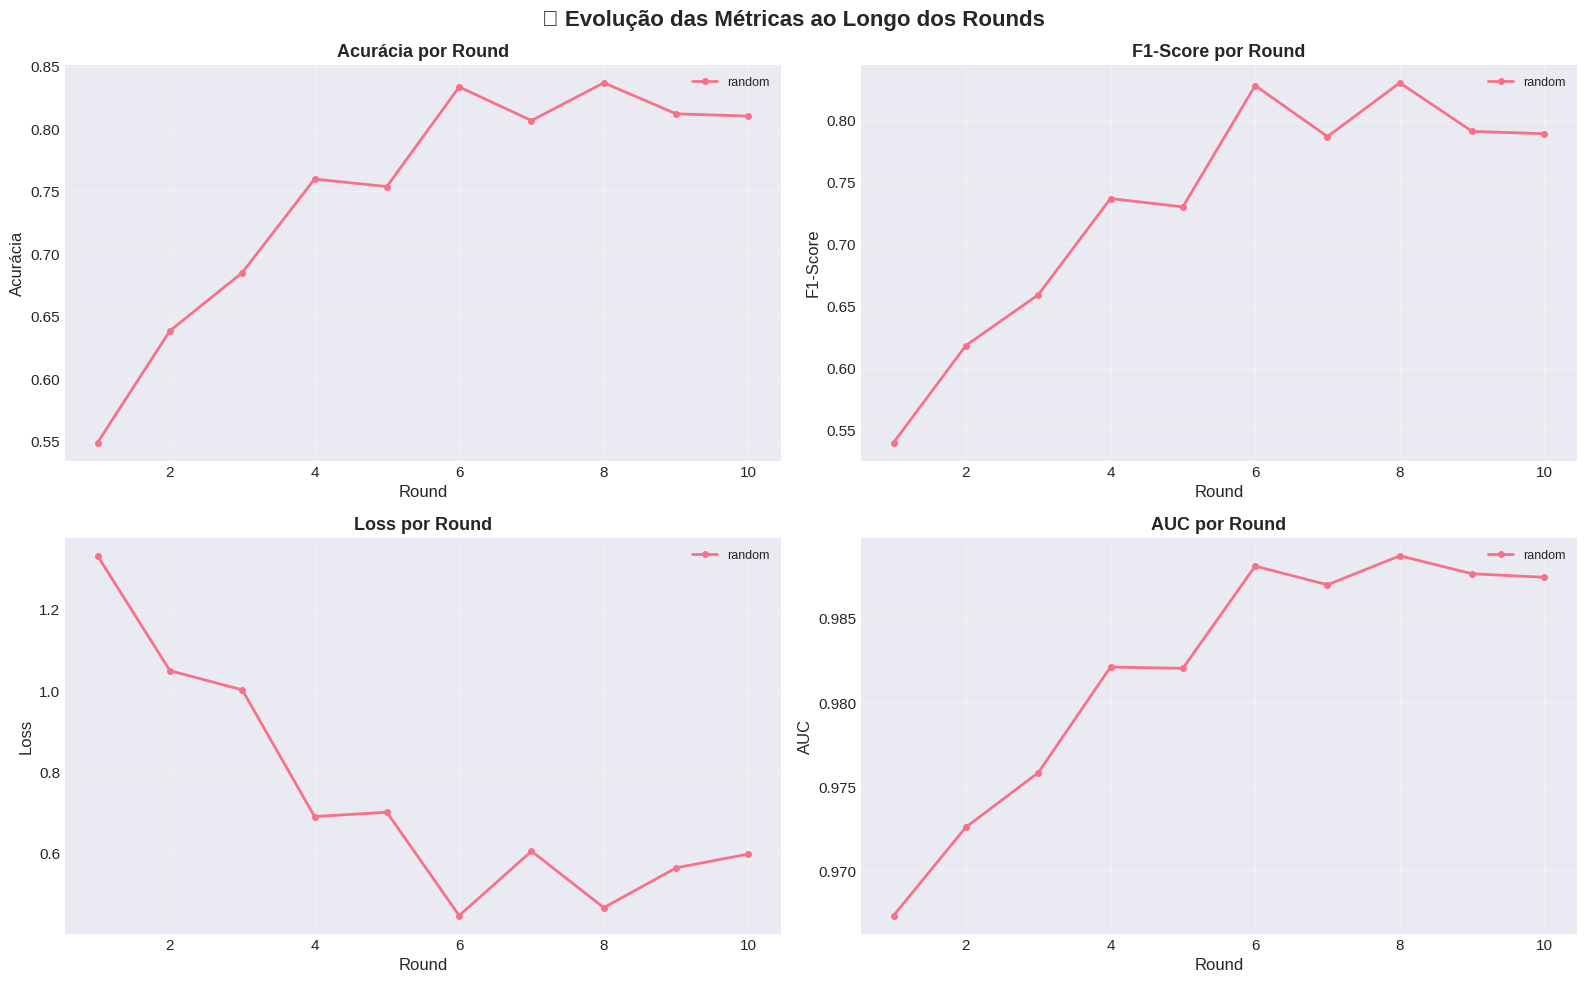


📊 Gráficos de convergência gerados!


In [43]:
# Plotar evolução da acurácia ao longo dos rounds
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("📈 Evolução das Métricas ao Longo dos Rounds", fontsize=16, fontweight="bold")

metrics_to_plot = [
    ("accuracy", "Acurácia"),
    ("f1_score", "F1-Score"),
    ("loss", "Loss"),
    ("auc", "AUC"),
]

for idx, (metric, label) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    for experiment in sorted(server_df["experiment"].unique()):
        data = server_df[server_df["experiment"] == experiment]
        ax.plot(
            data["rounds"], data[metric], marker="o", label=experiment, linewidth=2, markersize=4
        )

    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f"{label} por Round", fontsize=13, fontweight="bold")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Gráficos de convergência gerados!")

🚀 TAXA DE CONVERGÊNCIA (Melhoria de Acurácia)


,experiment,initial_accuracy,final_accuracy,total_improvement,num_rounds,avg_improvement_per_round
0,random,0.5488,0.81,0.2612,10,0.02612


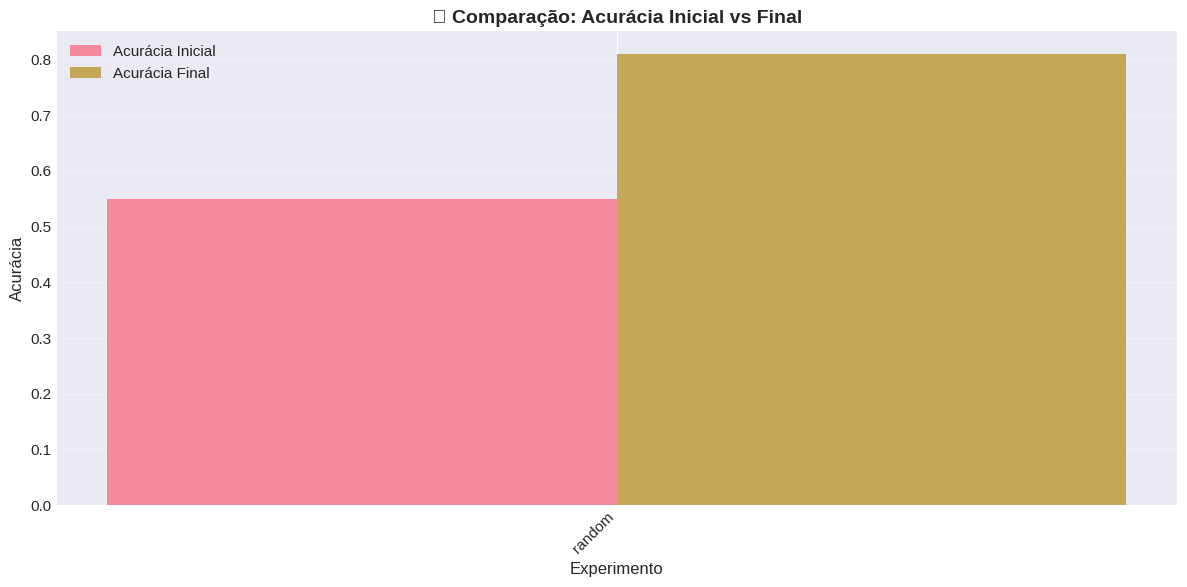

In [44]:
# Calcular taxa de convergência (melhoria por round)
print("=" * 80)
print("🚀 TAXA DE CONVERGÊNCIA (Melhoria de Acurácia)")
print("=" * 80)

convergence_stats = []

for experiment in sorted(server_df["experiment"].unique()):
    data = server_df[server_df["experiment"] == experiment].sort_values("rounds")

    if len(data) < 2:
        continue

    initial_acc = data["accuracy"].iloc[0]
    final_acc = data["accuracy"].iloc[-1]
    improvement = final_acc - initial_acc
    num_rounds = len(data)
    avg_improvement_per_round = improvement / num_rounds

    convergence_stats.append(
        {
            "experiment": experiment,
            "initial_accuracy": initial_acc,
            "final_accuracy": final_acc,
            "total_improvement": improvement,
            "num_rounds": num_rounds,
            "avg_improvement_per_round": avg_improvement_per_round,
        }
    )

convergence_df = pd.DataFrame(convergence_stats)
convergence_df = convergence_df.sort_values("final_accuracy", ascending=False)

display(convergence_df)

# Plotar comparação de convergência
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(convergence_df))
width = 0.35

ax.bar(
    x - width / 2, convergence_df["initial_accuracy"], width, label="Acurácia Inicial", alpha=0.8
)
ax.bar(x + width / 2, convergence_df["final_accuracy"], width, label="Acurácia Final", alpha=0.8)

ax.set_xlabel("Experimento", fontsize=12)
ax.set_ylabel("Acurácia", fontsize=12)
ax.set_title("📊 Comparação: Acurácia Inicial vs Final", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(convergence_df["experiment"], rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 6️⃣ Análise de Fairness e Participação dos Clientes


In [45]:
# Analisar frequência de seleção de cada cliente
print("=" * 80)
print("👥 ANÁLISE DE SELEÇÃO DE CLIENTES")
print("=" * 80)


def analyze_client_selection(df: pd.DataFrame, experiment_name: str) -> pd.DataFrame:
    """Analisa a frequência de seleção de cada cliente"""
    exp_data = df[df["experiment"] == experiment_name]

    # Contar seleções por cliente
    all_selections = []
    for clients in exp_data["selected_clients"]:
        all_selections.extend(clients)

    if not all_selections:
        return None

    selection_counts = pd.Series(all_selections).value_counts().sort_index()
    total_rounds = len(exp_data)

    return pd.DataFrame(
        {
            "client_id": selection_counts.index,
            "times_selected": selection_counts.values,
            "selection_rate": selection_counts.values / total_rounds,
        }
    )


# Analisar para cada experimento
selection_analysis = {}

for experiment in sorted(server_df["experiment"].unique()):
    analysis = analyze_client_selection(server_df, experiment)
    if analysis is not None:
        selection_analysis[experiment] = analysis

        print(f"\n📌 {experiment.upper()}")
        print("-" * 60)
        display(analysis)

        # Calcular métricas de fairness
        std_selection = analysis["times_selected"].std()
        mean_selection = analysis["times_selected"].mean()
        cv = std_selection / mean_selection if mean_selection > 0 else 0  # Coeficiente de variação

        print("\n📊 Métricas de Fairness:")
        print(f"  - Desvio padrão: {std_selection:.2f}")
        print(f"  - Coeficiente de variação: {cv:.4f} (quanto menor, mais justo)")

👥 ANÁLISE DE SELEÇÃO DE CLIENTES

📌 RANDOM
------------------------------------------------------------


,client_id,times_selected,selection_rate
0,0,4,0.4
1,1,3,0.3
2,2,8,0.8
3,3,7,0.7
4,4,10,1.0



📊 Métricas de Fairness:
  - Desvio padrão: 2.88
  - Coeficiente de variação: 0.4502 (quanto menor, mais justo)


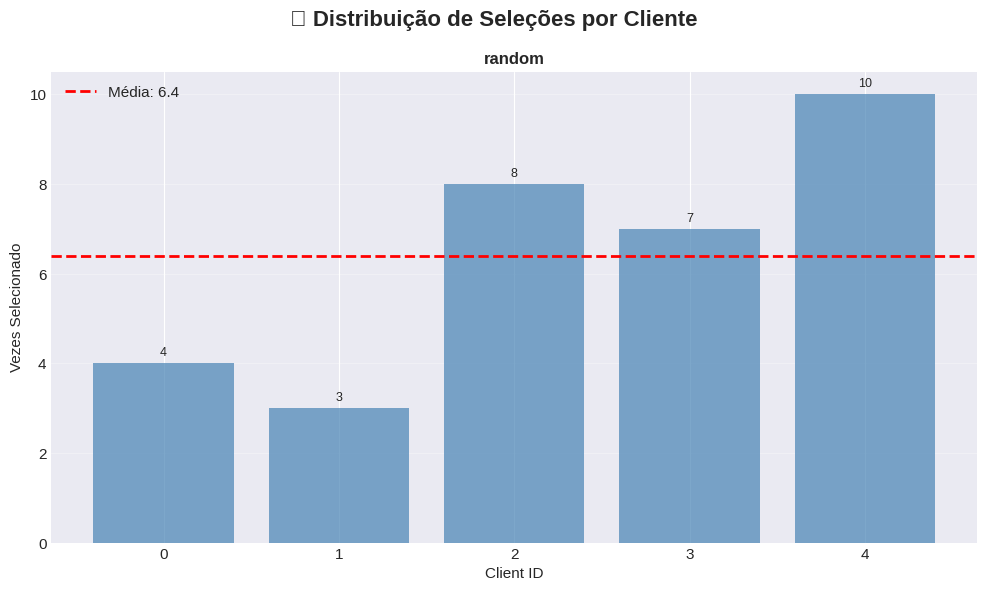

In [46]:
# Visualizar distribuição de seleções
num_experiments = len(selection_analysis)

# Criar subplots adequadamente baseado no número de experimentos
if num_experiments == 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    axes = [ax]
else:
    nrows = (num_experiments + 1) // 2
    fig, axes_array = plt.subplots(nrows, 2, figsize=(16, 4 * nrows))
    axes = axes_array.flatten()

fig.suptitle("👥 Distribuição de Seleções por Cliente", fontsize=16, fontweight="bold")

for idx, (experiment, data) in enumerate(sorted(selection_analysis.items())):
    ax = axes[idx]

    ax.bar(data["client_id"], data["times_selected"], color="steelblue", alpha=0.7)
    ax.axhline(
        y=data["times_selected"].mean(),
        color="red",
        linestyle="--",
        label=f"Média: {data['times_selected'].mean():.1f}",
        linewidth=2,
    )

    ax.set_xlabel("Client ID", fontsize=11)
    ax.set_ylabel("Vezes Selecionado", fontsize=11)
    ax.set_title(f"{experiment}", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    # Adicionar valores nas barras
    for i, v in enumerate(data["times_selected"]):
        ax.text(data["client_id"].iloc[i], v + 0.1, str(v), ha="center", va="bottom", fontsize=9)

# Remover eixos extras se houver (apenas se temos mais de 1 experimento)
if num_experiments > 1:
    for idx in range(len(selection_analysis), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


⚖️ COMPARAÇÃO DE FAIRNESS ENTRE EXPERIMENTOS

(Coeficiente de Variação e Gini: quanto menor, mais justo)



,experiment,mean_selections,std_selections,cv,gini_coefficient,min_selections,max_selections
0,random,6.4,2.880972,0.450152,0.225,3,10


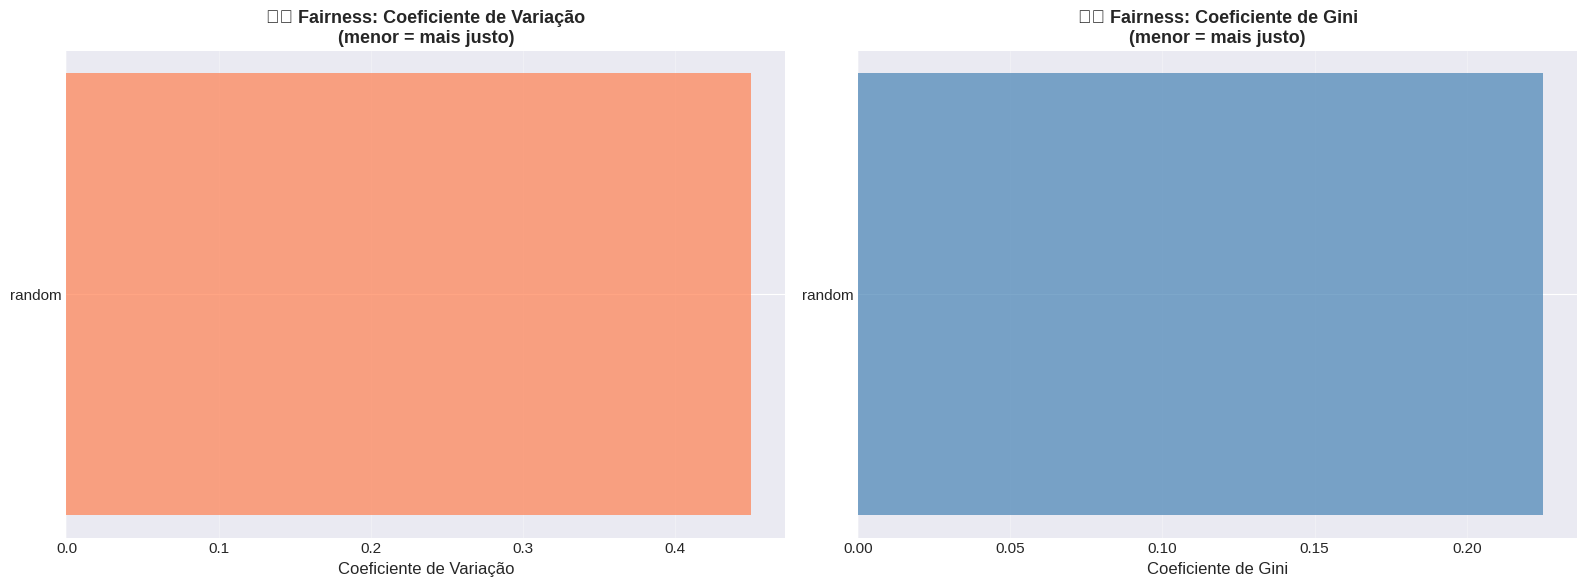

In [47]:
# Calcular coeficiente de Gini
def calculate_gini_coefficient(x: np.ndarray) -> float:
    """Calcula o coeficiente de Gini (0 = perfeitamente igual, 1 = perfeitamente desigual)"""
    sorted_x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(sorted_x)
    return (2 * np.sum((np.arange(1, n + 1)) * sorted_x)) / (n * cumsum[-1]) - (n + 1) / n


# Comparar fairness entre experimentos
fairness_comparison = []

for experiment, data in selection_analysis.items():
    std_selection = data["times_selected"].std()
    mean_selection = data["times_selected"].mean()
    cv = std_selection / mean_selection if mean_selection > 0 else 0
    gini = calculate_gini_coefficient(data["times_selected"].values)

    fairness_comparison.append(
        {
            "experiment": experiment,
            "mean_selections": mean_selection,
            "std_selections": std_selection,
            "cv": cv,
            "gini_coefficient": gini,
            "min_selections": data["times_selected"].min(),
            "max_selections": data["times_selected"].max(),
        }
    )

fairness_df = pd.DataFrame(fairness_comparison).sort_values("cv")

print("\n" + "=" * 80)
print("⚖️ COMPARAÇÃO DE FAIRNESS ENTRE EXPERIMENTOS")
print("=" * 80)
print("\n(Coeficiente de Variação e Gini: quanto menor, mais justo)\n")
display(fairness_df)

# Plotar comparação de fairness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CV
ax1.barh(fairness_df["experiment"], fairness_df["cv"], color="coral", alpha=0.7)
ax1.set_xlabel("Coeficiente de Variação", fontsize=12)
ax1.set_title(
    "⚖️ Fairness: Coeficiente de Variação\n(menor = mais justo)", fontsize=13, fontweight="bold"
)
ax1.grid(True, alpha=0.3, axis="x")

# Gini
ax2.barh(fairness_df["experiment"], fairness_df["gini_coefficient"], color="steelblue", alpha=0.7)
ax2.set_xlabel("Coeficiente de Gini", fontsize=12)
ax2.set_title(
    "⚖️ Fairness: Coeficiente de Gini\n(menor = mais justo)", fontsize=13, fontweight="bold"
)
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## 7️⃣ Análise Detalhada dos Clientes


In [48]:
if client_df is not None:
    print("=" * 80)
    print("👤 ANÁLISE DE PERFORMANCE DOS CLIENTES")
    print("=" * 80)

    # Métricas de teste por cliente
    client_metrics = ["eval_test_accuracy", "eval_test_f1_score", "eval_test_loss"]

    for experiment in sorted(client_df["experiment"].unique())[
        :3
    ]:  # Limitar para não ficar muito extenso
        print(f"\n📌 EXPERIMENTO: {experiment.upper()}")
        print("-" * 60)

        exp_data = client_df[client_df["experiment"] == experiment]

        # Performance final de cada cliente
        final_performance = exp_data.groupby("cid")[client_metrics].last()
        final_performance = final_performance.sort_values("eval_test_accuracy", ascending=False)

        print("\n📊 Performance Final de Cada Cliente (últimas métricas):")
        display(final_performance)

        # Estatísticas de participação
        participation_stats = (
            exp_data.groupby("cid")
            .agg({"selected": "sum", "participating_state": "count", "eval_test_accuracy": "mean"})
            .rename(
                columns={
                    "selected": "times_selected",
                    "participating_state": "total_rounds",
                    "eval_test_accuracy": "avg_test_accuracy",
                }
            )
        )
        participation_stats["selection_rate"] = (
            participation_stats["times_selected"] / participation_stats["total_rounds"]
        )

        print("\n📊 Estatísticas de Participação:")
        display(participation_stats)
else:
    print("⚠️ Dados de cliente não disponíveis para análise detalhada")

👤 ANÁLISE DE PERFORMANCE DOS CLIENTES

📌 EXPERIMENTO: RANDOM
------------------------------------------------------------

📊 Performance Final de Cada Cliente (últimas métricas):


,eval_test_accuracy,eval_test_f1_score,eval_test_loss
cid,,,
0,0.8615,0.864335,0.375138
2,0.8125,0.785093,0.642516
4,0.8030,0.771602,0.683812
3,0.7965,0.764139,0.696227
1,0.7765,0.760579,0.593775



📊 Estatísticas de Participação:


,times_selected,total_rounds,avg_test_accuracy,selection_rate
cid,,,,
0,4,4,0.741500,1.0
1,3,3,0.700667,1.0
2,8,8,0.758750,1.0
3,7,7,0.768000,1.0
4,10,10,0.771150,1.0


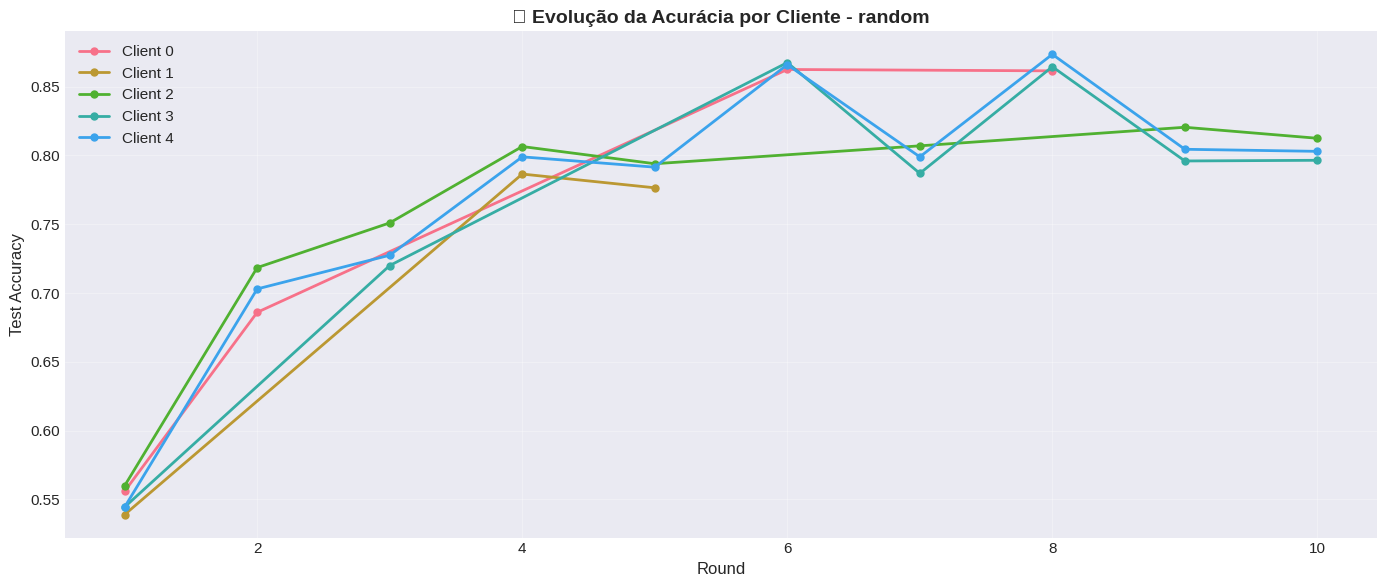

In [49]:
if client_df is not None:
    # Plotar evolução da acurácia de cada cliente ao longo do tempo
    experiments_to_plot = sorted(client_df["experiment"].unique())[:2]  # Limitar para visualização

    for experiment in experiments_to_plot:
        exp_data = client_df[client_df["experiment"] == experiment]

        fig, ax = plt.subplots(figsize=(14, 6))

        for cid in sorted(exp_data["cid"].unique()):
            client_data = exp_data[exp_data["cid"] == cid].sort_values("rounds")
            ax.plot(
                client_data["rounds"],
                client_data["eval_test_accuracy"],
                marker="o",
                label=f"Client {cid}",
                linewidth=2,
                markersize=5,
            )

        ax.set_xlabel("Round", fontsize=12)
        ax.set_ylabel("Test Accuracy", fontsize=12)
        ax.set_title(
            f"📈 Evolução da Acurácia por Cliente - {experiment}", fontsize=14, fontweight="bold"
        )
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

## 8️⃣ Comparação Entre Estratégias


In [51]:
# Criar tabela comparativa final
print("=" * 80)
print("📋 TABELA COMPARATIVA FINAL")
print("=" * 80)

comparison_table = []

for experiment in sorted(server_df["experiment"].unique()):
    exp_data = server_df[server_df["experiment"] == experiment]

    # Pegar métricas finais
    final_metrics = exp_data.iloc[-1]

    # Calcular melhorias
    initial_acc = exp_data["accuracy"].iloc[0]
    final_acc = final_metrics["accuracy"]
    improvement = final_acc - initial_acc

    # Fairness
    if experiment in selection_analysis:
        fairness_data = fairness_df[fairness_df["experiment"] == experiment].iloc[0]
        cv = fairness_data["cv"]
        gini = fairness_data["gini_coefficient"]
    else:
        cv = None
        gini = None

    comparison_table.append(
        {
            "Experimento": experiment,
            "Seleção": final_metrics["selection_method"],
            "Agregação": final_metrics["aggregation_method"],
            "Treinamento": final_metrics["training_method"],
            "Rounds": len(exp_data),
            "Acc Inicial": f"{initial_acc:.4f}",
            "Acc Final": f"{final_acc:.4f}",
            "Melhoria": f"{improvement:.4f}",
            "F1-Score Final": f"{final_metrics['f1_score']:.4f}",
            "AUC Final": f"{final_metrics['auc']:.4f}",
            "Loss Final": f"{final_metrics['loss']:.4f}",
            "CV Fairness": f"{cv:.4f}" if cv is not None else "N/A",
            "Gini": f"{gini:.4f}" if gini is not None else "N/A",
        }
    )

comparison_df = pd.DataFrame(comparison_table)
comparison_df = comparison_df.sort_values("Acc Final", ascending=False)

display(comparison_df)

# Exportar para CSV
output_path = "../logs/comparison_summary.csv"
comparison_df.to_csv(output_path, index=False)
print(f"\n✅ Tabela comparativa salva em: {output_path}")

📋 TABELA COMPARATIVA FINAL


,Experimento,Seleção,Agregação,Treinamento,Rounds,Acc Inicial,Acc Final,Melhoria,F1-Score Final,AUC Final,Loss Final,CV Fairness,Gini
0,random,random,fedavg,normal,10,0.5488,0.8100,0.2612,0.7891,0.9874,0.5983,0.4502,0.2250



✅ Tabela comparativa salva em: ../logs/comparison_summary.csv


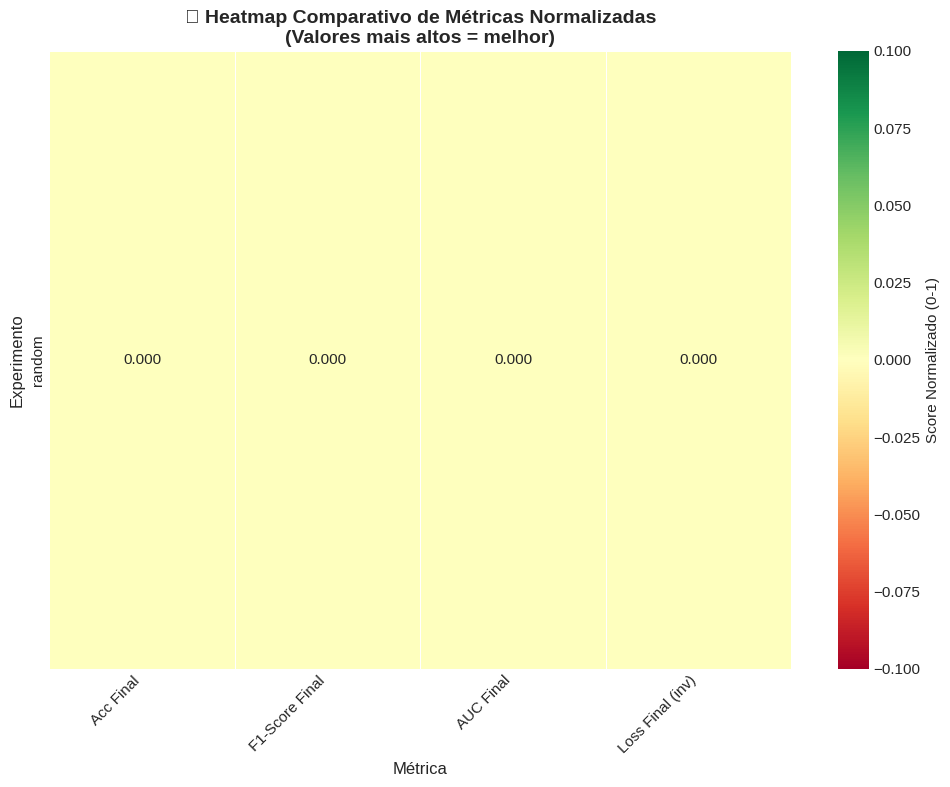

In [52]:
# Criar heatmap de métricas normalizadas
from sklearn.preprocessing import MinMaxScaler

# Preparar dados para heatmap
heatmap_data = comparison_df[["Experimento", "Acc Final", "F1-Score Final", "AUC Final"]].copy()
heatmap_data["Loss Final"] = comparison_df["Loss Final"]

# Converter strings para float
for col in ["Acc Final", "F1-Score Final", "AUC Final", "Loss Final"]:
    heatmap_data[col] = heatmap_data[col].astype(float)

# Inverter loss (quanto menor, melhor)
heatmap_data["Loss Final (inv)"] = 1 / (1 + heatmap_data["Loss Final"])
heatmap_data = heatmap_data.drop("Loss Final", axis=1)

# Normalizar
scaler = MinMaxScaler()
numeric_cols = heatmap_data.columns[1:]
heatmap_data[numeric_cols] = scaler.fit_transform(heatmap_data[numeric_cols])

# Plotar heatmap
plt.figure(figsize=(10, 8))
heatmap_matrix = heatmap_data.set_index("Experimento")[numeric_cols]

sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    cbar_kws={"label": "Score Normalizado (0-1)"},
    linewidths=0.5,
)
plt.title(
    "🔥 Heatmap Comparativo de Métricas Normalizadas\n(Valores mais altos = melhor)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Experimento", fontsize=12)
plt.xlabel("Métrica", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9️⃣ Conclusões e Recomendações


In [53]:
print("=" * 80)
print("📝 CONCLUSÕES E RECOMENDAÇÕES")
print("=" * 80)

# Melhor acurácia
best_accuracy = comparison_df.iloc[0]
print("\n🏆 MELHOR ACURÁCIA:")
print(f"   Experimento: {best_accuracy['Experimento']}")
print(f"   Acurácia Final: {best_accuracy['Acc Final']}")
print(f"   F1-Score: {best_accuracy['F1-Score Final']}")

# Melhor fairness
if not fairness_df.empty:
    best_fairness = fairness_df.iloc[0]
    print("\n⚖️ MELHOR FAIRNESS:")
    print(f"   Experimento: {best_fairness['experiment']}")
    print(f"   Coeficiente de Variação: {best_fairness['cv']:.4f}")
    print(f"   Coeficiente de Gini: {best_fairness['gini_coefficient']:.4f}")

# Maior melhoria
comparison_df["Melhoria_float"] = comparison_df["Melhoria"].astype(float)
best_improvement = comparison_df.loc[comparison_df["Melhoria_float"].idxmax()]
print("\n🚀 MAIOR MELHORIA:")
print(f"   Experimento: {best_improvement['Experimento']}")
print(f"   Melhoria: {best_improvement['Melhoria']}")

print("\n" + "=" * 80)
print("💡 RECOMENDAÇÕES:")
print("=" * 80)
print("""
1. Para ALTA ACURÁCIA: Use a estratégia com melhor performance final
2. Para FAIRNESS: Prefira estratégias com menor CV e Gini (ex: round_robin)
3. Para CONVERGÊNCIA RÁPIDA: Analise as taxas de melhoria por round
4. Para CENÁRIOS NÃO-IID: Considere estratégias específicas (LetsFed, MaxFL, QFFL)
5. REPRODUTIBILIDADE: Sempre configure seeds fixas para resultados determinísticos

⚠️ PRÓXIMOS PASSOS:
- Executar experimentos com mais rounds para validar convergência
- Testar em diferentes datasets (CIFAR-10, MNIST, etc.)
- Validar em cenários com diferentes níveis de heterogeneidade
- Comparar com baselines da literatura
""")

print("\n✅ Análise completa finalizada!")

📝 CONCLUSÕES E RECOMENDAÇÕES

🏆 MELHOR ACURÁCIA:
   Experimento: random
   Acurácia Final: 0.8100
   F1-Score: 0.7891

⚖️ MELHOR FAIRNESS:
   Experimento: random
   Coeficiente de Variação: 0.4502
   Coeficiente de Gini: 0.2250

🚀 MAIOR MELHORIA:
   Experimento: random
   Melhoria: 0.2612

💡 RECOMENDAÇÕES:

1. Para ALTA ACURÁCIA: Use a estratégia com melhor performance final
2. Para FAIRNESS: Prefira estratégias com menor CV e Gini (ex: round_robin)
3. Para CONVERGÊNCIA RÁPIDA: Analise as taxas de melhoria por round
4. Para CENÁRIOS NÃO-IID: Considere estratégias específicas (LetsFed, MaxFL, QFFL)
5. REPRODUTIBILIDADE: Sempre configure seeds fixas para resultados determinísticos

⚠️ PRÓXIMOS PASSOS:
- Executar experimentos com mais rounds para validar convergência
- Testar em diferentes datasets (CIFAR-10, MNIST, etc.)
- Validar em cenários com diferentes níveis de heterogeneidade
- Comparar com baselines da literatura


✅ Análise completa finalizada!


## 🔟 Exportar Resultados


In [ ]:
# Criar diretório para resultados se não existir
results_dir = Path("../logs/analysis_results")
results_dir.mkdir(exist_ok=True)

# Exportar dados processados
server_df.to_csv(results_dir / "server_data_processed.csv", index=False)
if client_df is not None:
    client_df.to_csv(results_dir / "client_data_processed.csv", index=False)

# Exportar análises
convergence_df.to_csv(results_dir / "convergence_analysis.csv", index=False)
fairness_df.to_csv(results_dir / "fairness_analysis.csv", index=False)
comparison_df.to_csv(results_dir / "final_comparison.csv", index=False)

# Exportar seleções de clientes
for experiment, data in selection_analysis.items():
    filename = f"selection_analysis_{experiment}.csv"
    data.to_csv(results_dir / filename, index=False)

print(f"✅ Todos os resultados exportados para: {results_dir}")
print("\nArquivos gerados:")
for file in sorted(results_dir.glob("*.csv")):
    print(f"  - {file.name}")